# P4.0 — Setup preprocessing baseline

Memuat dataset dari `images/`, membaca `ground_truth.csv` dengan pola parser dari `eda_ocr.ipynb`, cross-check filename, memilih sample kecil lintas ukuran, dan menyiapkan output/log.

In [1]:
from pathlib import Path
import csv
import json
import shutil
import numpy as np
import pandas as pd
from PIL import Image

PROJECT_ROOT = Path.cwd()
IMAGES_DIR = PROJECT_ROOT / 'images'
GROUND_TRUTH_PATH = PROJECT_ROOT / 'ground_truth.csv'
OUTPUT_DIR = PROJECT_ROOT / 'preprocessed' / 'baseline'
LOG_DIR = OUTPUT_DIR / 'logs'
SAMPLE_DIR = OUTPUT_DIR / 'sample'
for folder in (OUTPUT_DIR, LOG_DIR, SAMPLE_DIR):
    folder.mkdir(parents=True, exist_ok=True)

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tiff', '.tif'}
print(f'Project root: {PROJECT_ROOT}')
print(f'Output: {OUTPUT_DIR}')

Project root: e:\comp\compfest_final_proj
Output: e:\comp\compfest_final_proj\preprocessed\baseline


In [2]:
# Parser mengikuti eda_ocr.ipynb: mendukung baris yang dibungkus quote tambahan.
def parse_ground_truth_row(line):
    line = line.rstrip('\r\n')
    if line.startswith('\"') and line.endswith('\"'):
        line = line[1:-1].replace('\"\"', '\"')
    return next(csv.reader([line]))

with GROUND_TRUTH_PATH.open('r', encoding='utf-8-sig') as f:
    reader = csv.reader(f)
    gt_columns = next(reader)
with GROUND_TRUTH_PATH.open('r', encoding='utf-8-sig') as f:
    next(f)
    gt_rows = [parse_ground_truth_row(line) for line in f if line.strip()]
invalid_rows = [(i + 2, row) for i, row in enumerate(gt_rows) if len(row) != len(gt_columns)]
if invalid_rows:
    raise ValueError(f'Baris ground truth invalid: {invalid_rows[:5]}')
ground_truth_df = pd.DataFrame(gt_rows, columns=gt_columns)

image_files = sorted([p for p in IMAGES_DIR.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS])
image_names = {p.name for p in image_files}
gt_names = set(ground_truth_df['filename'].dropna().astype(str).str.strip())
images_without_gt = sorted(image_names - gt_names)
gt_without_image = sorted(gt_names - image_names)
print(f'Image files: {len(image_files)}')
print(f'Ground-truth rows: {len(ground_truth_df)}')
print(f'Matched filenames: {len(image_names & gt_names)}')
print(f'Images without ground truth: {len(images_without_gt)}')
print(f'Ground-truth filenames without image: {len(gt_without_image)}')

Image files: 732
Ground-truth rows: 632
Matched filenames: 632
Images without ground truth: 100
Ground-truth filenames without image: 0


In [3]:
# Metadata semua gambar + validasi file bisa dibuka.
records = []
for path in image_files:
    row = {'filename': path.name, 'path': str(path), 'file_size_bytes': path.stat().st_size, 'is_valid': False, 'error': ''}
    try:
        with Image.open(path) as image:
            row.update(width=image.width, height=image.height, mode=image.mode, format=image.format, is_valid=True)
    except Exception as exc:
        row['error'] = repr(exc)
    records.append(row)
image_df = pd.DataFrame(records)
image_df['has_ground_truth'] = image_df['filename'].isin(gt_names)
image_df['size_group'] = pd.qcut(image_df['file_size_bytes'], q=2, labels=['small', 'large'], duplicates='drop')
image_df.to_csv(LOG_DIR / 'image_inventory.csv', index=False)
ground_truth_df.to_csv(LOG_DIR / 'ground_truth_loaded.csv', index=False)
pd.DataFrame({'filename': images_without_gt}).to_csv(LOG_DIR / 'images_without_ground_truth.csv', index=False)
pd.DataFrame({'filename': gt_without_image}).to_csv(LOG_DIR / 'ground_truth_without_image.csv', index=False)

# 8 sample deterministik: 4 file kecil dan 4 file besar berdasarkan ukuran byte.
valid_df = image_df[image_df['is_valid']].sort_values('file_size_bytes')
sample_df = pd.concat([valid_df.head(4), valid_df.tail(4)]).drop_duplicates('filename')
sample_df = sample_df.sort_values(['size_group', 'file_size_bytes']).reset_index(drop=True)
for filename in sample_df['filename']:
    shutil.copy2(IMAGES_DIR / filename, SAMPLE_DIR / filename)
sample_df.to_csv(LOG_DIR / 'sample_manifest.csv', index=False)

summary = {
    'image_count': len(image_files), 'ground_truth_count': len(ground_truth_df),
    'matched_count': len(image_names & gt_names), 'images_without_ground_truth': len(images_without_gt),
    'ground_truth_without_image': len(gt_without_image), 'valid_image_count': int(image_df['is_valid'].sum()),
    'sample_count': len(sample_df), 'sample_filenames': sample_df['filename'].tolist()
}
(LOG_DIR / 'setup_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
display(sample_df[['filename', 'width', 'height', 'file_size_bytes', 'size_group', 'has_ground_truth']])
print('Setup selesai; log tersimpan di', LOG_DIR)

,filename,width,height,file_size_bytes,size_group,has_ground_truth
0,image_097.jpg,197,124,5311,small,True
1,image_091.jpg,289,117,8039,small,True
2,image_076.jpg,291,175,8361,small,True
3,image_095.jpg,285,179,9704,small,True
4,image_020.jpg,4608,3456,1282653,large,True
5,image_033.jpg,4608,3456,1456929,large,True
6,image_019.jpg,4608,3456,1675083,large,True
7,image_018.jpg,4608,3456,2011932,large,True


Setup selesai; log tersimpan di e:\comp\compfest_final_proj\preprocessed\baseline\logs


## P4.1 — Load & Validasi

Loader membaca image dengan error handling, memastikan hasil akhir berupa array RGB 3-channel, menguji sample, lalu menjalankan validasi ke seluruh dataset.

In [4]:
def read_image_rgb(image_path):
    """Baca image dan kembalikan ndarray RGB (H, W, 3)."""
    try:
        with Image.open(image_path) as image:
            original_mode = image.mode
            image.load()
            rgb = np.asarray(image.convert('RGB'))
        if rgb.ndim != 3 or rgb.shape[2] != 3:
            return None, 'hasil bukan RGB 3-channel'
        return rgb, ''
    except Exception as exc:
        return None, f'{type(exc).__name__}: {exc}'

def validate_image_path(image_path):
    array, reason = read_image_rgb(image_path)
    return {
        'filename': image_path.name,
        'status': 'ok' if array is not None else 'failed',
        'reason': reason,
        'height': int(array.shape[0]) if array is not None else None,
        'width': int(array.shape[1]) if array is not None else None,
        'channels': int(array.shape[2]) if array is not None and array.ndim == 3 else None,
    }

# Test sample sebelum full run.
sample_paths = [SAMPLE_DIR / name for name in sample_df['filename']]
sample_validation_df = pd.DataFrame([validate_image_path(path) for path in sample_paths])
display(sample_validation_df)
assert (sample_validation_df['status'] == 'ok').all(), 'Sample memiliki image yang gagal dibaca'
assert (sample_validation_df['channels'] == 3).all(), 'Sample tidak seluruhnya RGB 3-channel'

,filename,status,reason,height,width,channels
0,image_097.jpg,ok,,124,197,3
1,image_091.jpg,ok,,117,289,3
2,image_076.jpg,ok,,175,291,3
3,image_095.jpg,ok,,179,285,3
4,image_020.jpg,ok,,3456,4608,3
5,image_033.jpg,ok,,3456,4608,3
6,image_019.jpg,ok,,3456,4608,3
7,image_018.jpg,ok,,3456,4608,3


In [5]:
# Full run ke seluruh dataset. Log satu baris per file.
validation_df = pd.DataFrame([validate_image_path(path) for path in image_files])
validation_df = validation_df.sort_values('filename').reset_index(drop=True)
validation_log_path = LOG_DIR / 'image_load_validation.csv'
validation_df.to_csv(validation_log_path, index=False)

ok_count = int((validation_df['status'] == 'ok').sum())
failed_count = int((validation_df['status'] == 'failed').sum())
rgb_count = int((validation_df['channels'] == 3).sum())
print(f'OK: {ok_count}/{len(validation_df)}')
print(f'Failed: {failed_count}/{len(validation_df)}')
print(f'RGB 3-channel: {rgb_count}/{len(validation_df)}')
if failed_count:
    display(validation_df[validation_df['status'] == 'failed'])
else:
    print('Tidak ada file corrupt/gagal load.')
print(f'Log tersimpan di: {validation_log_path}')

OK: 732/732
Failed: 0/732
RGB 3-channel: 732/732
Tidak ada file corrupt/gagal load.
Log tersimpan di: e:\comp\compfest_final_proj\preprocessed\baseline\logs\image_load_validation.csv


## P4.2 — Resize (Cap Max Dimension, No Upscale + Low-Res Flagging)

Cap generik diterapkan pada long-side semua gambar. Gambar hanya di-downscale jika long-side melebihi cap; gambar yang lebih kecil dibiarkan pada ukuran asli. Flag `very_low_res` hanya untuk visibility, tanpa treatment khusus.

In [6]:
RESIZE_CAP = 1800
VERY_LOW_RES_THRESHOLD = 300
RESIZED_DIR = OUTPUT_DIR / 'resized'
RESIZED_DIR.mkdir(parents=True, exist_ok=True)
print(f'Resize cap long-side: {RESIZE_CAP}px')
print(f'Low-res threshold: long-side < {VERY_LOW_RES_THRESHOLD}px')

Resize cap long-side: 1800px
Low-res threshold: long-side < 300px


In [7]:
def resize_image_no_upscale(image, cap=RESIZE_CAP):
    """Resize proporsional dengan cap long-side; tidak pernah upscale."""
    original_width, original_height = image.size
    original_long_side = max(original_width, original_height)
    if original_long_side > cap:
        scale = cap / original_long_side
        final_size = (max(1, round(original_width * scale)), max(1, round(original_height * scale)))
        resized = image.resize(final_size, Image.Resampling.LANCZOS)
        downscaled = True
    else:
        resized = image.copy()
        final_size = (original_width, original_height)
        downscaled = False
    return resized, downscaled, final_size

In [8]:
# Test sample wajib mencakup 4K dan low-res ekstrem dari dataset.
sample_resize_names = list(dict.fromkeys(['image_018.jpg', 'image_097.jpg', 'image_091.jpg'] + sample_df['filename'].tolist()))
sample_resize_rows = []
for filename in sample_resize_names:
    with Image.open(IMAGES_DIR / filename) as source:
        original_size = source.size
        resized, downscaled, final_size = resize_image_no_upscale(source)
    original_long = max(original_size)
    sample_resize_rows.append({
        'filename': filename, 'original_width': original_size[0], 'original_height': original_size[1],
        'final_width': final_size[0], 'final_height': final_size[1], 'downscaled': downscaled,
        'very_low_res': original_long < VERY_LOW_RES_THRESHOLD,
        'aspect_ratio_preserved': abs(original_size[0] / original_size[1] - final_size[0] / final_size[1]) < 0.01,
    })
sample_resize_df = pd.DataFrame(sample_resize_rows)
display(sample_resize_df)
assert (sample_resize_df['final_width'] <= RESIZE_CAP).all() and (sample_resize_df['final_height'] <= RESIZE_CAP).all()
assert (sample_resize_df['final_width'] <= sample_resize_df['original_width']).all()
assert (sample_resize_df['final_height'] <= sample_resize_df['original_height']).all()
assert sample_resize_df['aspect_ratio_preserved'].all()

,filename,original_width,original_height,final_width,final_height,downscaled,very_low_res,aspect_ratio_preserved
0,image_018.jpg,4608,3456,1800,1350,True,False,True
1,image_097.jpg,197,124,197,124,False,True,True
2,image_091.jpg,289,117,289,117,False,True,True
3,image_076.jpg,291,175,291,175,False,True,True
4,image_095.jpg,285,179,285,179,False,True,True
5,image_020.jpg,4608,3456,1800,1350,True,False,True
6,image_033.jpg,4608,3456,1800,1350,True,False,True
7,image_019.jpg,4608,3456,1800,1350,True,False,True


In [9]:
# Full run: simpan semua hasil dalam format RGB JPEG agar output konsisten.
resize_records = []
for source_path in image_files:
    record = {'filename': source_path.name, 'status': 'failed', 'reason': ''}
    try:
        with Image.open(source_path) as source:
            rgb = source.convert('RGB')
            original_width, original_height = rgb.size
            resized, downscaled, (final_width, final_height) = resize_image_no_upscale(rgb)
            resized.save(RESIZED_DIR / source_path.name, format='JPEG', quality=95)
        original_long = max(original_width, original_height)
        record.update({
            'status': 'ok', 'original_width': original_width, 'original_height': original_height,
            'original_long_side': original_long, 'final_width': final_width, 'final_height': final_height,
            'final_long_side': max(final_width, final_height), 'downscaled': downscaled,
            'very_low_res': original_long < VERY_LOW_RES_THRESHOLD,
        })
    except Exception as exc:
        record['reason'] = f'{type(exc).__name__}: {exc}'
    resize_records.append(record)

resize_log_df = pd.DataFrame(resize_records).sort_values('filename').reset_index(drop=True)
resize_log_path = LOG_DIR / 'resize_log.csv'
resize_log_df.to_csv(resize_log_path, index=False)
print(f'Berhasil di-resize: {(resize_log_df.status == "ok").sum()}/{len(resize_log_df)}')
print(f'Downscaled: {int(resize_log_df.downscaled.fillna(False).sum())}')
print(f'Dibiarkan: {int((~resize_log_df.downscaled.fillna(False)).sum())}')
print(f'Very low resolution: {int(resize_log_df.very_low_res.fillna(False).sum())}')
print(f'Output: {RESIZED_DIR}')
print(f'Log: {resize_log_path}')

Berhasil di-resize: 732/732
Downscaled: 425
Dibiarkan: 307
Very low resolution: 10
Output: e:\comp\compfest_final_proj\preprocessed\baseline\resized
Log: e:\comp\compfest_final_proj\preprocessed\baseline\logs\resize_log.csv


## P4.3 — Contrast Normalization Ringan

Input tahap ini adalah output P4.2 (`resized/`). Contrast stretch diterapkan pada kanal luminance LAB menggunakan percentile 1–99 agar warna tetap natural dan outlier tidak menyebabkan over-stretch ekstrem.

In [10]:
NORMALIZATION_METHOD = 'LAB_L_percentile_minmax'
LOW_PERCENTILE = 1.0
HIGH_PERCENTILE = 99.0
NORMALIZED_DIR = OUTPUT_DIR / 'normalized'
NORMALIZED_DIR.mkdir(parents=True, exist_ok=True)
print(f'Method: {NORMALIZATION_METHOD}')
print(f'Parameters: low={LOW_PERCENTILE}%, high={HIGH_PERCENTILE}%')

Method: LAB_L_percentile_minmax
Parameters: low=1.0%, high=99.0%


In [11]:
def luminance_array(image):
    return np.asarray(image.convert('LAB'), dtype=np.uint8)[:, :, 0].astype(np.float32)

def normalize_contrast_lab(image, low_percentile=LOW_PERCENTILE, high_percentile=HIGH_PERCENTILE):
    """Stretch kanal L LAB ke 0..255, lalu kembalikan RGB tanpa stretch per-channel."""
    lab = np.asarray(image.convert('LAB'), dtype=np.uint8).copy()
    luminance = lab[:, :, 0].astype(np.float32)
    low, high = np.percentile(luminance, [low_percentile, high_percentile])
    if high <= low:
        return image.convert('RGB').copy(), float(low), float(high)
    stretched = np.clip((luminance - low) * 255.0 / (high - low), 0, 255).astype(np.uint8)
    lab[:, :, 0] = stretched
    return Image.fromarray(lab, mode='LAB').convert('RGB'), float(low), float(high)

In [12]:
def normalization_metrics(before, after):
    before_l = luminance_array(before)
    after_l = luminance_array(after)
    return {
        'original_brightness_mean': float(before_l.mean()),
        'final_brightness_mean': float(after_l.mean()),
        'final_l_clip_low_ratio': float(np.mean(after_l <= 0)),
        'final_l_clip_high_ratio': float(np.mean(after_l >= 255)),
    }

# Sample brightness: ambil 2 paling gelap, 2 paling terang, plus semua very_low_res.
resize_log_df = pd.read_csv(LOG_DIR / 'resize_log.csv')
sample_brightness_names = list(dict.fromkeys(
    resize_log_df.nsmallest(2, 'original_long_side')['filename'].tolist()
    + resize_log_df.nsmallest(2, 'original_width')['filename'].tolist()
    + resize_log_df[resize_log_df['very_low_res'] == True]['filename'].tolist()
    + ['image_018.jpg']
))
sample_norm_rows = []
for filename in sample_brightness_names:
    with Image.open(RESIZED_DIR / filename) as source:
        source_rgb = source.convert('RGB')
        normalized, low, high = normalize_contrast_lab(source_rgb)
        metrics = normalization_metrics(source_rgb, normalized)
    sample_norm_rows.append({'filename': filename, 'stretch_low': low, 'stretch_high': high, **metrics})
sample_norm_df = pd.DataFrame(sample_norm_rows)
display(sample_norm_df)
# Sanity threshold 10%: percentile stretch boleh menghasilkan sedikit clipping,
# tetapi tidak boleh membuat mayoritas area menjadi hitam/putih.
assert (sample_norm_df['final_l_clip_low_ratio'] < 0.10).all()
assert (sample_norm_df['final_l_clip_high_ratio'] < 0.10).all()

,filename,stretch_low,stretch_high,original_brightness_mean,final_brightness_mean,final_l_clip_low_ratio,final_l_clip_high_ratio
0,image_097.jpg,58.0,215.0,157.556778,161.235184,0.000000,0.000000
1,image_085.jpg,63.0,222.0,156.049896,148.542816,0.000321,0.000000
2,image_065.jpg,56.0,232.0,150.709869,136.812149,0.000040,0.000218
3,image_066.jpg,54.0,234.0,159.255600,148.709000,0.000647,0.003801
4,image_076.jpg,85.0,240.0,176.482056,150.061996,0.002514,0.000530
5,image_087.jpg,65.0,215.0,169.373932,176.580307,0.000247,0.000000
6,image_091.jpg,4.0,255.0,186.435837,184.822464,0.001922,0.053293
7,image_095.jpg,65.0,236.0,161.958145,144.221725,0.000059,0.000000
8,image_099.jpg,66.0,230.0,170.360153,161.730850,0.000000,0.000000
9,image_100.jpg,43.0,248.0,138.885956,118.909874,0.004486,0.007365


In [13]:
# Full run dari output P4.2 saja.
normalized_records = []
resized_files = sorted([p for p in RESIZED_DIR.iterdir() if p.is_file() and p.suffix.lower() == '.jpg'])
for source_path in resized_files:
    record = {'filename': source_path.name, 'status': 'failed', 'reason': '', 'method': NORMALIZATION_METHOD,
              'low_percentile': LOW_PERCENTILE, 'high_percentile': HIGH_PERCENTILE}
    try:
        with Image.open(source_path) as source:
            source_rgb = source.convert('RGB')
            normalized, low, high = normalize_contrast_lab(source_rgb)
            output_path = NORMALIZED_DIR / source_path.name
            # Hapus output parsial dari run sebelumnya sebelum menulis ulang.
            if output_path.exists(): output_path.unlink()
            normalized.save(output_path, format='JPEG', quality=95)
        record.update({'status': 'ok', 'stretch_low': low, 'stretch_high': high, **normalization_metrics(source_rgb, normalized)})
    except Exception as exc:
        record['reason'] = f'{type(exc).__name__}: {exc}'
    normalized_records.append(record)

normalization_log_df = pd.DataFrame(normalized_records).sort_values('filename').reset_index(drop=True)
normalization_log_path = LOG_DIR / 'contrast_normalization_log.csv'
normalization_log_df.to_csv(normalization_log_path, index=False)
print(f'Berhasil dinormalisasi: {(normalization_log_df.status == "ok").sum()}/{len(normalization_log_df)}')
print(f'Rata-rata brightness: {normalization_log_df.original_brightness_mean.mean():.2f} -> {normalization_log_df.final_brightness_mean.mean():.2f}')
print(f'Rata-rata clipping L rendah/tinggi: {normalization_log_df.final_l_clip_low_ratio.mean():.4f} / {normalization_log_df.final_l_clip_high_ratio.mean():.4f}')
print(f'Output: {NORMALIZED_DIR}')
print(f'Log: {normalization_log_path}')

Berhasil dinormalisasi: 730/732
Rata-rata brightness: 118.33 -> 132.33
Rata-rata clipping L rendah/tinggi: 0.0180 / 0.0020
Output: e:\comp\compfest_final_proj\preprocessed\baseline\normalized
Log: e:\comp\compfest_final_proj\preprocessed\baseline\logs\contrast_normalization_log.csv


## P4.4 — Save Output + Consolidated Logging

Menggabungkan log load, resize, dan normalisasi menjadi satu deliverable per filename.

In [14]:
load_log = pd.read_csv(LOG_DIR / 'image_load_validation.csv')
resize_log = pd.read_csv(LOG_DIR / 'resize_log.csv')
contrast_log = pd.read_csv(LOG_DIR / 'contrast_normalization_log.csv')

consolidated_log_df = (
    load_log[['filename', 'status', 'reason', 'width', 'height', 'channels']]
    .rename(columns={'status': 'load_status', 'reason': 'load_failure_reason', 'width': 'original_width', 'height': 'original_height'})
    .merge(resize_log[['filename', 'status', 'final_width', 'final_height', 'downscaled', 'very_low_res']], on='filename', how='outer', suffixes=('', '_resize'))
    .merge(contrast_log[['filename', 'status', 'method', 'low_percentile', 'high_percentile', 'original_brightness_mean', 'final_brightness_mean', 'final_l_clip_low_ratio', 'final_l_clip_high_ratio']], on='filename', how='outer', suffixes=('', '_contrast'))
)
consolidated_log_df = consolidated_log_df.rename(columns={'status': 'resize_status', 'status_contrast': 'contrast_status'})
if 'status_contrast' not in consolidated_log_df.columns and 'contrast_status' not in consolidated_log_df.columns:
    # Pandas only adds a suffix when there is a collision; normalize whichever form exists.
    status_columns = [c for c in consolidated_log_df.columns if c.startswith('status')]
    if 'status_y' in status_columns: consolidated_log_df = consolidated_log_df.rename(columns={'status_y': 'contrast_status'})
consolidated_log_df['final_output'] = consolidated_log_df['filename'].map(lambda name: str(NORMALIZED_DIR / name))
consolidated_log_df['final_output_exists'] = consolidated_log_df['filename'].map(lambda name: (NORMALIZED_DIR / name).is_file())
consolidated_log_df['pipeline_status'] = np.where(
    (consolidated_log_df['load_status'] == 'ok') & consolidated_log_df['final_output_exists'], 'ok', 'failed'
)
# P4.1–P4.3 sebelumnya belum menginstrumentasikan durasi per-file; pertahankan kolom
# eksplisit agar baseline log siap diisi pada rerun terinstrumentasi.
consolidated_log_df['process_time_seconds'] = np.nan
consolidated_log_df = consolidated_log_df.sort_values('filename').reset_index(drop=True)
consolidated_path = LOG_DIR / 'p4_baseline_consolidated_log.csv'
consolidated_log_df.to_csv(consolidated_path, index=False)
print(f'Consolidated rows: {len(consolidated_log_df)}')
print(f'Pipeline OK: {(consolidated_log_df.pipeline_status == "ok").sum()}')
print(f'Consolidated log: {consolidated_path}')

Consolidated rows: 732
Pipeline OK: 732
Consolidated log: e:\comp\compfest_final_proj\preprocessed\baseline\logs\p4_baseline_consolidated_log.csv


In [15]:
# Spot-check random reproducible: file final harus bisa dibuka, RGB, dan ukurannya sama dengan log.
spotcheck_df = consolidated_log_df.sample(n=min(10, len(consolidated_log_df)), random_state=42).copy()
spotcheck_rows = []
for _, row in spotcheck_df.iterrows():
    path = Path(row['final_output'])
    try:
        with Image.open(path) as image:
            rgb = image.convert('RGB')
            spotcheck_rows.append({'filename': row['filename'], 'readable': True, 'rgb_channels': len(rgb.getbands()), 'width': rgb.width, 'height': rgb.height, 'matches_log': (rgb.width == row['final_width'] and rgb.height == row['final_height'])})
    except Exception as exc:
        spotcheck_rows.append({'filename': row['filename'], 'readable': False, 'rgb_channels': None, 'width': None, 'height': None, 'matches_log': False, 'reason': repr(exc)})
spotcheck_result_df = pd.DataFrame(spotcheck_rows)
spotcheck_result_df.to_csv(LOG_DIR / 'spotcheck_random.csv', index=False)
display(spotcheck_result_df)
assert spotcheck_result_df['readable'].all()
assert (spotcheck_result_df['rgb_channels'] == 3).all()
assert spotcheck_result_df['matches_log'].all()
print('Spot-check random berhasil.')

,filename,readable,rgb_channels,width,height,matches_log
0,image_605.jpg,True,3,1012,1800,True
1,image_034.jpg,True,3,480,360,True
2,image_301.jpg,True,3,800,500,True
3,image_458.jpg,True,3,1012,1800,True
4,image_635.jpg,True,3,1012,1800,True
5,image_558.jpg,True,3,1012,1800,True
6,image_040.jpg,True,3,314,209,True
7,image_357.jpg,True,3,1012,1800,True
8,image_727.jpg,True,3,1012,1800,True
9,image_516.jpg,True,3,1012,1800,True


Spot-check random berhasil.


## P4.5 — Review & Sanity Check

Review akhir pipeline: jumlah file, grid before/after, distribusi ukuran, dan dokumentasi isu.

In [16]:
import matplotlib.pyplot as plt

review_dir = OUTPUT_DIR / 'review'
review_dir.mkdir(parents=True, exist_ok=True)
review_log = pd.read_csv(LOG_DIR / 'p4_baseline_consolidated_log.csv')
input_count = len(image_files)
output_count = len(list(NORMALIZED_DIR.glob('*.jpg')))
print(f'Input images: {input_count}')
print(f'Final outputs: {output_count}')
assert input_count == output_count == len(review_log)
print('Sanity count PASS: output == input == consolidated log')

Input images: 732
Final outputs: 732
Sanity count PASS: output == input == consolidated log


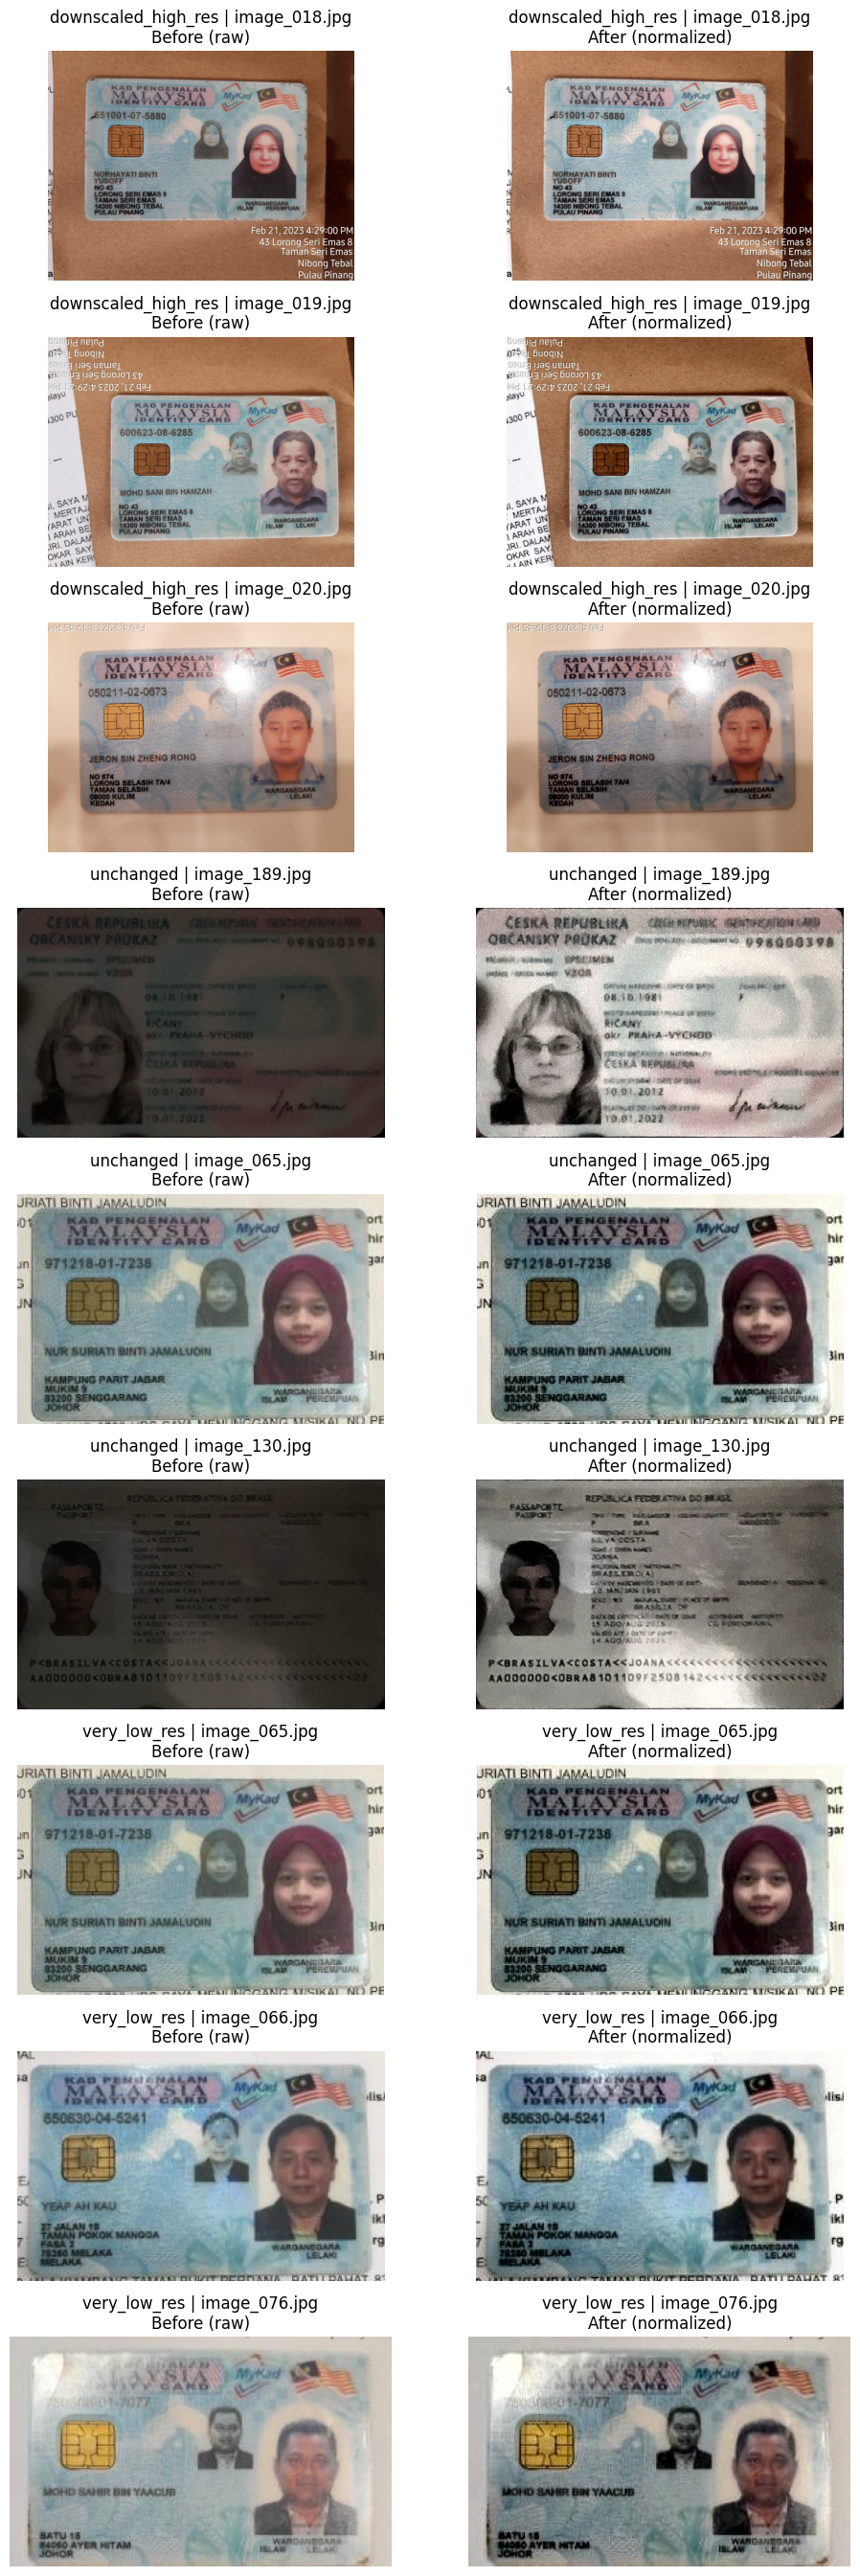

Grid saved: e:\comp\compfest_final_proj\preprocessed\baseline\review\before_after_grid.png


In [17]:
# Representative visual grid: downscaled, unchanged, very-low-res, dan high-res.
groups = {
    'downscaled_high_res': review_log[review_log['downscaled'] == True].sort_values('original_width', ascending=False).head(3),
    'unchanged': review_log[review_log['downscaled'] == False].sample(n=min(3, (review_log['downscaled'] == False).sum()), random_state=42),
    'very_low_res': review_log[review_log['very_low_res'] == True].head(3),
}
grid_rows = []
for group_name, group in groups.items():
    for _, row in group.iterrows():
        filename = row['filename']
        with Image.open(IMAGES_DIR / filename) as before, Image.open(NORMALIZED_DIR / filename) as after:
            grid_rows.append((group_name, filename, before.convert('RGB').copy(), after.convert('RGB').copy()))
fig, axes = plt.subplots(len(grid_rows), 2, figsize=(10, max(4, 3 * len(grid_rows))))
axes = np.atleast_2d(axes)
for i, (group_name, filename, before, after) in enumerate(grid_rows):
    for ax, image, title in [(axes[i, 0], before, 'Before (raw)'), (axes[i, 1], after, 'After (normalized)')]:
        ax.imshow(image); ax.axis('off'); ax.set_title(f'{group_name} | {filename}\n{title}')
fig.tight_layout()
fig.savefig(review_dir / 'before_after_grid.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(fig)
print('Grid saved:', review_dir / 'before_after_grid.png')

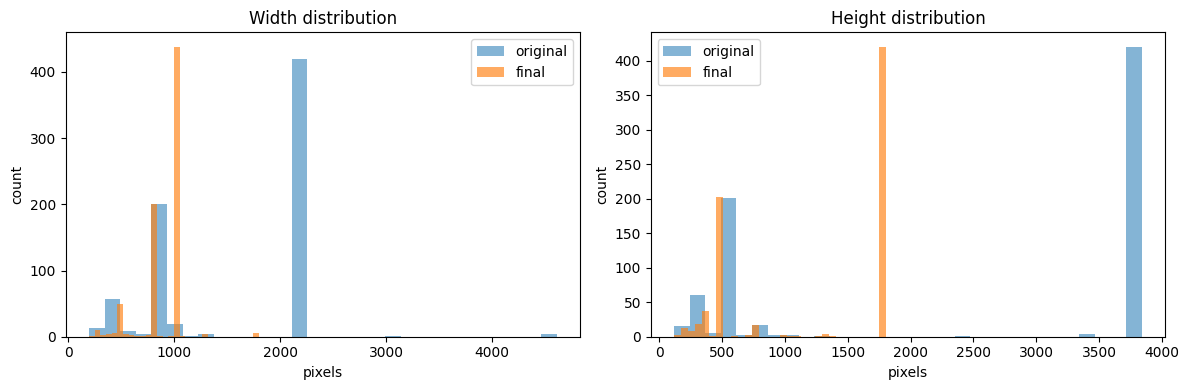

       original_width  original_height  final_width  final_height
count          732.00           732.00       732.00        732.00
mean          1575.31          2425.86       899.47       1242.49
std            751.22          1660.44       199.02        657.96
min            197.00           117.00       197.00        117.00
25%            800.00           500.00       800.00        500.00
50%           2160.00          3840.00      1012.00       1800.00
75%           2160.00          3840.00      1012.00       1800.00
max           4608.00          3840.00      1800.00       1800.00


In [18]:
# Histogram final vs original dimensions.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(review_log['original_width'].dropna(), bins=30, alpha=0.55, label='original')
axes[0].hist(review_log['final_width'].dropna(), bins=30, alpha=0.65, label='final')
axes[0].set_title('Width distribution'); axes[0].set_xlabel('pixels'); axes[0].set_ylabel('count'); axes[0].legend()
axes[1].hist(review_log['original_height'].dropna(), bins=30, alpha=0.55, label='original')
axes[1].hist(review_log['final_height'].dropna(), bins=30, alpha=0.65, label='final')
axes[1].set_title('Height distribution'); axes[1].set_xlabel('pixels'); axes[1].set_ylabel('count'); axes[1].legend()
fig.tight_layout(); fig.savefig(review_dir / 'size_distribution_before_after.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(fig)
print(review_log[['original_width','original_height','final_width','final_height']].describe().round(2))

In [19]:
# Issue summary untuk dokumentasi baseline P4.
clip_risk = review_log[(review_log['final_l_clip_low_ratio'] >= 0.10) | (review_log['final_l_clip_high_ratio'] >= 0.10)]
issues = {
    'input_count': int(input_count), 'output_count': int(output_count),
    'load_failed': int((review_log['load_status'] != 'ok').sum()),
    'pipeline_failed': int((review_log['pipeline_status'] != 'ok').sum()),
    'very_low_res': int(review_log['very_low_res'].fillna(False).sum()),
    'clip_risk_ge_10_percent': int(len(clip_risk)),
    'mean_clip_low_ratio': float(review_log['final_l_clip_low_ratio'].mean()),
    'mean_clip_high_ratio': float(review_log['final_l_clip_high_ratio'].mean()),
    'notes': ['very_low_res images remain in the same pipeline; flag is visibility only.']
}
(review_dir / 'p4_review_summary.json').write_text(json.dumps(issues, indent=2), encoding='utf-8')
pd.DataFrame([issues]).to_csv(review_dir / 'p4_review_summary.csv', index=False)
print(json.dumps(issues, indent=2))

{
  "input_count": 732,
  "output_count": 732,
  "load_failed": 0,
  "pipeline_failed": 0,
  "very_low_res": 10,
  "clip_risk_ge_10_percent": 38,
  "mean_clip_low_ratio": 0.017987839129533455,
  "mean_clip_high_ratio": 0.0020125992982892066,
  "notes": [
    "very_low_res images remain in the same pipeline; flag is visibility only."
  ]
}
